# 🔍 Exploration des Données (Analyse Exploratoire)

Bienvenue dans ce notebook consacré à l'**exploration des données** !

Avant de créer un modèle d'IA, il est indispensable de **bien comprendre ses données**. C'est ce qu'on appelle l'**Analyse Exploratoire des Données** (EDA – *Exploratory Data Analysis*).

## Table des matières
1. [Chargement des données](#1)
2. [Informations générales](#2)
3. [Statistiques descriptives](#3)
4. [Visualisation des distributions](#4)
5. [Valeurs manquantes](#5)
6. [Corrélations](#6)
7. [Relations entre variables](#7)
8. [Conclusion](#8)

---
> 💡 **Objectif** : Apprendre à explorer un jeu de données avant toute modélisation.

## 📦 0. Importation des bibliothèques

In [1]:
# Bibliothèques essentielles pour l'exploration de données
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

# Style des graphiques
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('✅ Bibliothèques importées avec succès !')

✅ Bibliothèques importées avec succès !


## 1. Chargement des données <a id='1'></a>

Nous utiliserons le dataset **Iris**, un classique en apprentissage automatique :
- **150 observations** de fleurs
- **4 variables numériques** : longueur/largeur du sépale et du pétale
- **3 espèces** : Setosa, Versicolor, Virginica

In [2]:
# Chargement du dataset Iris
iris = load_iris(as_frame=True)
df = iris.frame

# Renommer les colonnes pour plus de clarté
df.columns = ['longueur_sepale', 'largeur_sepale', 'longueur_petale', 'largeur_petale', 'espece']
df['espece_nom'] = df['espece'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print('Dimensions du dataset :', df.shape)
print(f'  → {df.shape[0]} lignes (observations)')
print(f'  → {df.shape[1]} colonnes (variables)')
print()
print('Premières lignes du dataset :')
df.head(10)

Dimensions du dataset : (150, 6)
  → 150 lignes (observations)
  → 6 colonnes (variables)

Premières lignes du dataset :


,longueur_sepale,largeur_sepale,longueur_petale,largeur_petale,espece,espece_nom
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
5,5.4,3.9,1.7,0.4,0,setosa
6,4.6,3.4,1.4,0.3,0,setosa
7,5.0,3.4,1.5,0.2,0,setosa
8,4.4,2.9,1.4,0.2,0,setosa
9,4.9,3.1,1.5,0.1,0,setosa


## 2. Informations générales <a id='2'></a>

La méthode `.info()` donne un aperçu rapide du dataset :
- Les **types de données** (numérique, texte, etc.)
- Le **nombre de valeurs non-nulles** (pour détecter les valeurs manquantes)
- La **mémoire utilisée**

In [3]:
# Informations générales sur le dataset
print('=== Informations générales ===')
df.info()

=== Informations générales ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   longueur_sepale  150 non-null    float64
 1   largeur_sepale   150 non-null    float64
 2   longueur_petale  150 non-null    float64
 3   largeur_petale   150 non-null    float64
 4   espece           150 non-null    int64  
 5   espece_nom       150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [4]:
# Nombre de valeurs uniques par colonne
print('Types de données par colonne :')
print(df.dtypes)
print()
print('Nombre de valeurs uniques par colonne :')
print(df.nunique())
print()
print('Répartition des espèces :')
print(df['espece_nom'].value_counts())

Types de données par colonne :
longueur_sepale    float64
largeur_sepale     float64
longueur_petale    float64
largeur_petale     float64
espece               int64
espece_nom          object
dtype: object

Nombre de valeurs uniques par colonne :
longueur_sepale    35
largeur_sepale     23
longueur_petale    43
largeur_petale     22
espece              3
espece_nom          3
dtype: int64

Répartition des espèces :
espece_nom
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## 3. Statistiques descriptives <a id='3'></a>

La méthode `.describe()` calcule automatiquement les statistiques clés :

| Statistique | Signification |
|-------------|---------------|
| **count** | Nombre de valeurs |
| **mean** | Moyenne |
| **std** | Écart-type (dispersion) |
| **min / max** | Valeurs extrêmes |
| **25%, 50%, 75%** | Quartiles |

In [5]:
# Statistiques descriptives globales
print('=== Statistiques descriptives ===')
df.describe().round(2)

=== Statistiques descriptives ===


,longueur_sepale,largeur_sepale,longueur_petale,largeur_petale,espece
count,150.00,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20,1.00
std,0.83,0.44,1.77,0.76,0.82
min,4.30,2.00,1.00,0.10,0.00
25%,5.10,2.80,1.60,0.30,0.00
50%,5.80,3.00,4.35,1.30,1.00
75%,6.40,3.30,5.10,1.80,2.00
max,7.90,4.40,6.90,2.50,2.00


In [6]:
# Statistiques par espèce
print('=== Moyenne des mesures par espèce ===')
cols_num = ['longueur_sepale', 'largeur_sepale', 'longueur_petale', 'largeur_petale']
df.groupby('espece_nom')[cols_num].mean().round(2)

=== Moyenne des mesures par espèce ===


,longueur_sepale,largeur_sepale,longueur_petale,largeur_petale
espece_nom,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.59,2.97,5.55,2.03


## 4. Visualisation des distributions <a id='4'></a>

### 4.1 Histogrammes

Un histogramme montre la **distribution** d'une variable numérique : comment les valeurs se répartissent-elles ?

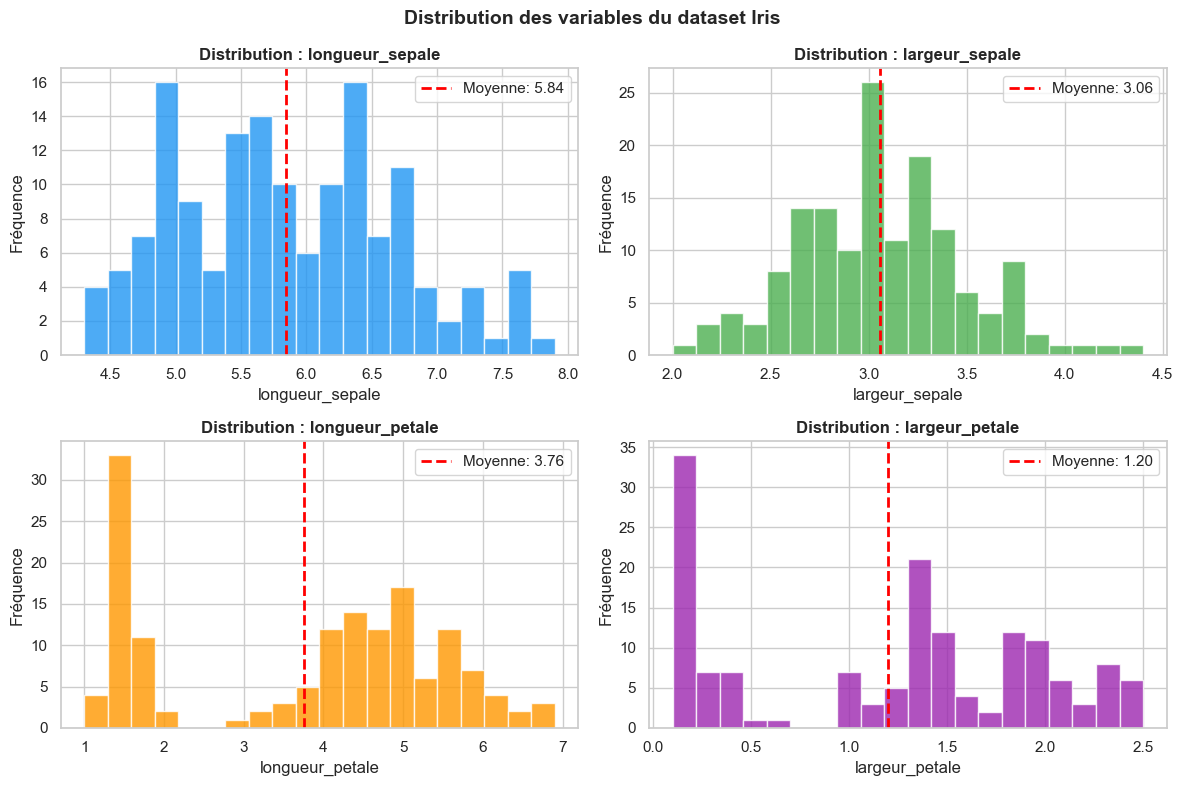

💡 La ligne rouge représente la moyenne de chaque variable.


In [7]:
# Histogrammes de toutes les variables numériques
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
couleurs = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for i, col in enumerate(cols_num):
    axes[i].hist(df[col], bins=20, color=couleurs[i], edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribution : {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Fréquence')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=2,
                    label=f'Moyenne: {df[col].mean():.2f}')
    axes[i].legend()

plt.suptitle('Distribution des variables du dataset Iris', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('💡 La ligne rouge représente la moyenne de chaque variable.')

### 4.2 Boîtes à moustaches (Boxplots)

Les boxplots permettent de comparer les distributions **par groupe** et de repérer les **valeurs aberrantes**.

/var/folders/pb/snzns2vx1v59ngzx14bljb640000gp/T/ipykernel_10109/2592041789.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='espece_nom', y=col, ax=axes[i], palette='Set2')
/var/folders/pb/snzns2vx1v59ngzx14bljb640000gp/T/ipykernel_10109/2592041789.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='espece_nom', y=col, ax=axes[i], palette='Set2')
/var/folders/pb/snzns2vx1v59ngzx14bljb640000gp/T/ipykernel_10109/2592041789.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='espece_nom', y=col, ax=axes[i],

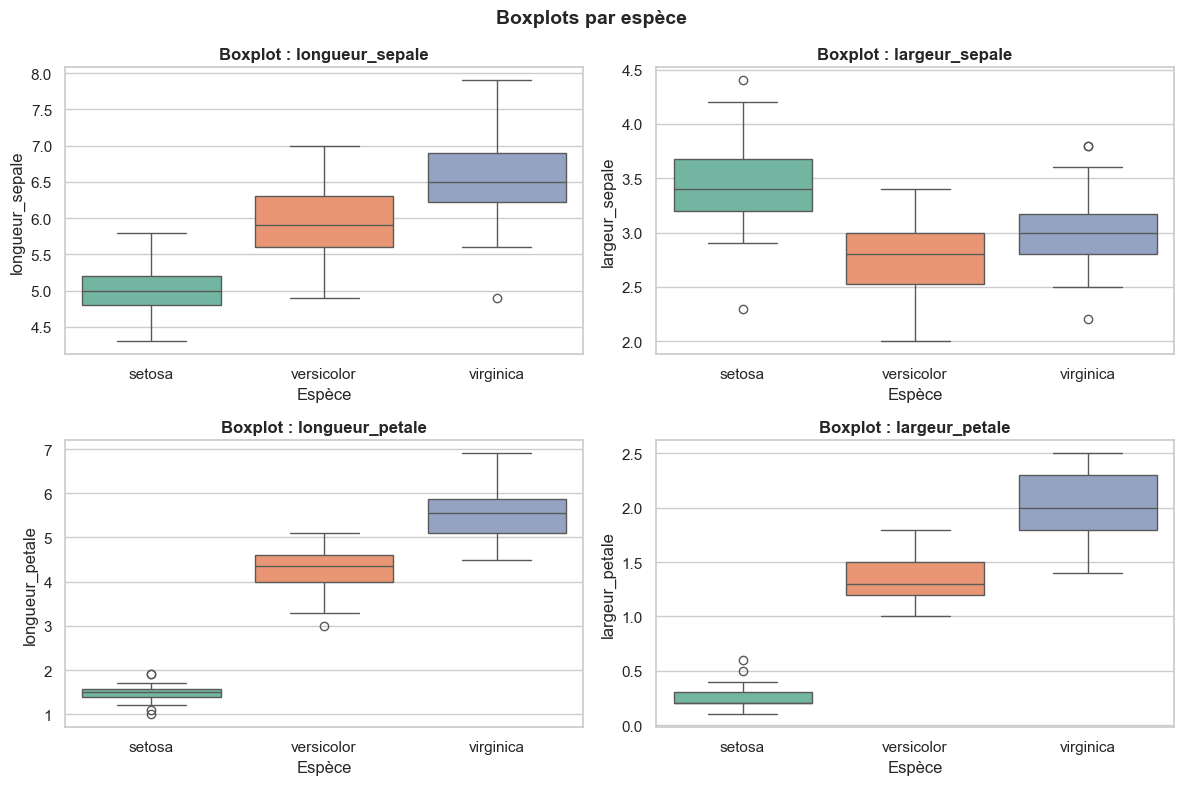

💡 Les points isolés = valeurs aberrantes (outliers).
   La ligne centrale = médiane.
   La boîte = 50% des données (de Q1 à Q3).


In [8]:
# Boxplots par espèce
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(cols_num):
    sns.boxplot(data=df, x='espece_nom', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Boxplot : {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Espèce')

plt.suptitle('Boxplots par espèce', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('💡 Les points isolés = valeurs aberrantes (outliers).')
print('   La ligne centrale = médiane.')
print('   La boîte = 50% des données (de Q1 à Q3).')

## 5. Valeurs manquantes <a id='5'></a>

Les valeurs manquantes sont très fréquentes dans les données réelles. Il faut les **identifier** et décider comment les traiter.

> ⚠️ Un modèle d'IA ne peut généralement pas traiter les valeurs manquantes directement.

In [9]:
# Vérification des valeurs manquantes
print('=== Valeurs manquantes - Dataset Iris ===')
print(df.isnull().sum())
print(f'\nTotal manquant : {df.isnull().sum().sum()}')
print('\n(Iris est un dataset propre - pas de valeurs manquantes)')

=== Valeurs manquantes - Dataset Iris ===
longueur_sepale    0
largeur_sepale     0
longueur_petale    0
largeur_petale     0
espece             0
espece_nom         0
dtype: int64

Total manquant : 0

(Iris est un dataset propre - pas de valeurs manquantes)


In [10]:
# Simulation de valeurs manquantes pour la démonstration
import numpy as np
np.random.seed(42)

df_demo = df[cols_num].copy()
for col in cols_num:
    idx = np.random.choice(len(df_demo), size=7, replace=False)
    df_demo.loc[idx, col] = np.nan

print('=== Exemple avec valeurs manquantes simulées ===')
print(df_demo.isnull().sum())
print(f'\nPourcentage manquant par colonne :')
print((df_demo.isnull().sum() / len(df_demo) * 100).round(1).astype(str) + ' %')

# Stratégies
print('\n=== Stratégies de traitement ===')
print(f'1. Supprimer les lignes : {len(df_demo)} → {len(df_demo.dropna())} lignes')
df_impute = df_demo.fillna(df_demo.mean())
print(f'2. Imputer par la moyenne : {df_demo.isnull().sum().sum()} → {df_impute.isnull().sum().sum()} valeurs manquantes')
print('💡 La médiane est préférée lorsqu\'il y a des valeurs aberrantes.')

=== Exemple avec valeurs manquantes simulées ===
longueur_sepale    7
largeur_sepale     7
longueur_petale    7
largeur_petale     7
dtype: int64

Pourcentage manquant par colonne :
longueur_sepale    4.7 %
largeur_sepale     4.7 %
longueur_petale    4.7 %
largeur_petale     4.7 %
dtype: object

=== Stratégies de traitement ===
1. Supprimer les lignes : 150 → 122 lignes
2. Imputer par la moyenne : 28 → 0 valeurs manquantes
💡 La médiane est préférée lorsqu'il y a des valeurs aberrantes.


## 6. Corrélations <a id='6'></a>

La **corrélation** mesure la **force et la direction de la relation linéaire** entre deux variables.

| Valeur | Interprétation |
|--------|----------------|
| **+1** | Corrélation positive parfaite |
| **0** | Aucune corrélation linéaire |
| **-1** | Corrélation négative parfaite |

### 6.1 Calcul de la matrice de corrélation

In [11]:
# Matrice de corrélation
corr_matrix = df[cols_num].corr()
print('=== Matrice de corrélation (méthode de Pearson) ===')
print(corr_matrix.round(2))

=== Matrice de corrélation (méthode de Pearson) ===
                 longueur_sepale  largeur_sepale  longueur_petale  \
longueur_sepale             1.00           -0.12             0.87   
largeur_sepale             -0.12            1.00            -0.43   
longueur_petale             0.87           -0.43             1.00   
largeur_petale              0.82           -0.37             0.96   

                 largeur_petale  
longueur_sepale            0.82  
largeur_sepale            -0.37  
longueur_petale            0.96  
largeur_petale             1.00  


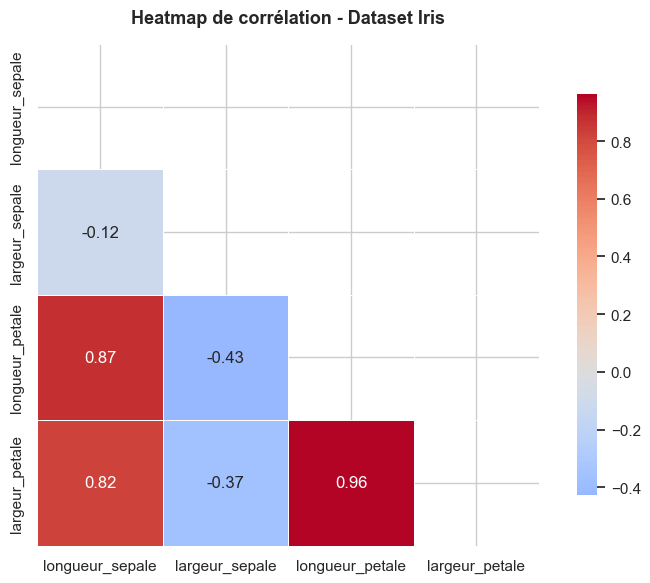


🔍 Lecture :
  → Rouge foncé = corrélation positive forte (proche de +1)
  → Bleu foncé  = corrélation négative forte (proche de -1)
  → Blanc       = pas de corrélation (proche de 0)


In [12]:
# Heatmap de corrélation
plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            mask=mask,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})

plt.title('Heatmap de corrélation - Dataset Iris', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print('\n🔍 Lecture :')
print('  → Rouge foncé = corrélation positive forte (proche de +1)')
print('  → Bleu foncé  = corrélation négative forte (proche de -1)')
print('  → Blanc       = pas de corrélation (proche de 0)')

### 6.2 Identifier les corrélations importantes

In [13]:
# Identifier les paires les plus corrélées
print('=== Top corrélations (valeur absolue) ===')

# Extraire le triangle inférieur (éviter les doublons)
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        var1 = corr_matrix.columns[i]
        var2 = corr_matrix.columns[j]
        r = corr_matrix.loc[var1, var2]
        corr_pairs.append((var1, var2, r))

# Trier par valeur absolue décroissante
corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

for var1, var2, r in corr_pairs:
    barre = '█' * int(abs(r) * 20)
    direction = '↗ positive' if r > 0 else '↘ négative'
    print(f'  {var1} ↔ {var2}')
    print(f'    r = {r:.3f} {barre} ({direction})')

=== Top corrélations (valeur absolue) ===
  longueur_petale ↔ largeur_petale
    r = 0.963 ███████████████████ (↗ positive)
  longueur_sepale ↔ longueur_petale
    r = 0.872 █████████████████ (↗ positive)
  longueur_sepale ↔ largeur_petale
    r = 0.818 ████████████████ (↗ positive)
  largeur_sepale ↔ longueur_petale
    r = -0.428 ████████ (↘ négative)
  largeur_sepale ↔ largeur_petale
    r = -0.366 ███████ (↘ négative)
  longueur_sepale ↔ largeur_sepale
    r = -0.118 ██ (↘ négative)


### 6.3 Pearson vs Spearman

Deux grandes méthodes de corrélation :
- **Pearson** : mesure les relations *linéaires*, suppose des données normales
- **Spearman** : basé sur les *rangs*, plus robuste aux outliers et aux relations non-linéaires

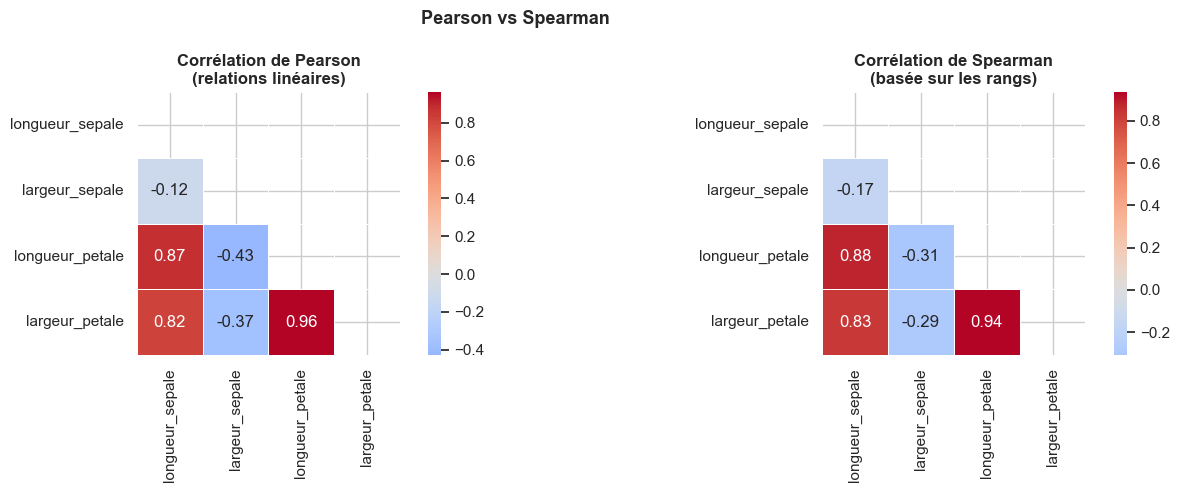

In [14]:
# Comparaison Pearson et Spearman
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pearson = df[cols_num].corr(method='pearson')
spearman = df[cols_num].corr(method='spearman')

mask = np.triu(np.ones_like(pearson, dtype=bool))

sns.heatmap(pearson, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, square=True, ax=axes[0], linewidths=0.5)
axes[0].set_title('Corrélation de Pearson\n(relations linéaires)', fontweight='bold')

sns.heatmap(spearman, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, square=True, ax=axes[1], linewidths=0.5)
axes[1].set_title('Corrélation de Spearman\n(basée sur les rangs)', fontweight='bold')

plt.suptitle('Pearson vs Spearman', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Relations entre variables <a id='7'></a>

### 7.1 Scatter plots avec ligne de tendance

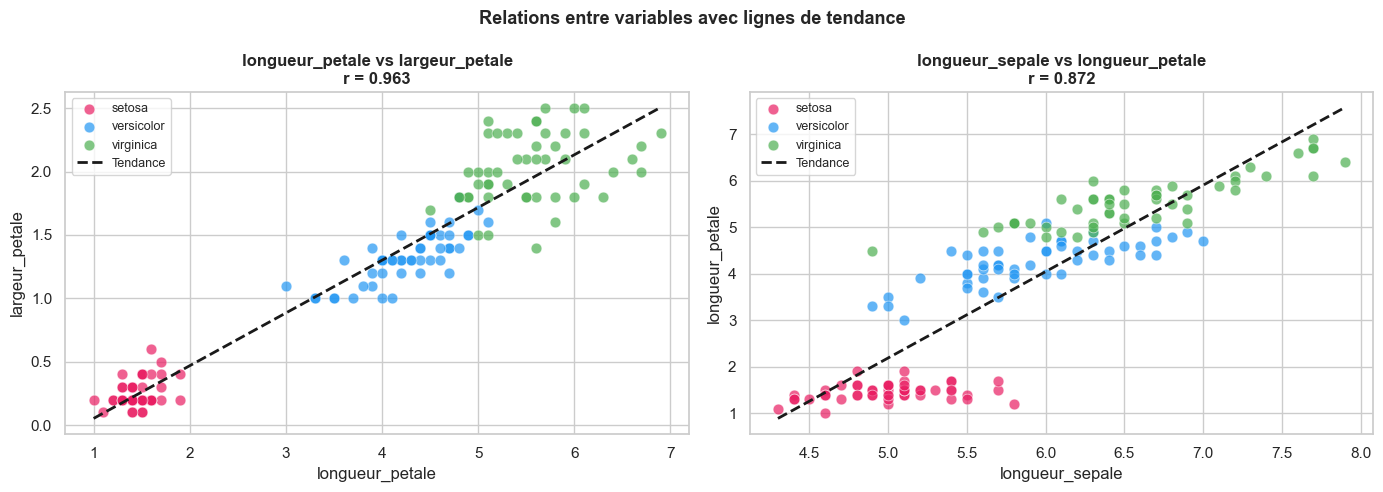

In [15]:
# Scatter plots avec ligne de tendance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
couleurs_esp = {'setosa': '#E91E63', 'versicolor': '#2196F3', 'virginica': '#4CAF50'}

paires = [('longueur_petale', 'largeur_petale'), ('longueur_sepale', 'longueur_petale')]

for ax, (x_col, y_col) in zip(axes, paires):
    for espece, groupe in df.groupby('espece_nom'):
        ax.scatter(groupe[x_col], groupe[y_col], alpha=0.7, s=60,
                   label=espece, color=couleurs_esp[espece], edgecolors='white', linewidth=0.5)
    
    # Ligne de tendance
    z = np.polyfit(df[x_col], df[y_col], 1)
    p = np.poly1d(z)
    x_range = np.linspace(df[x_col].min(), df[x_col].max(), 100)
    ax.plot(x_range, p(x_range), 'k--', linewidth=2, label=f'Tendance')
    
    r = df[x_col].corr(df[y_col])
    ax.set_title(f'{x_col} vs {y_col}\nr = {r:.3f}', fontweight='bold')
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.legend(fontsize=9)

plt.suptitle('Relations entre variables avec lignes de tendance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.2 Pair plot (vue d'ensemble)

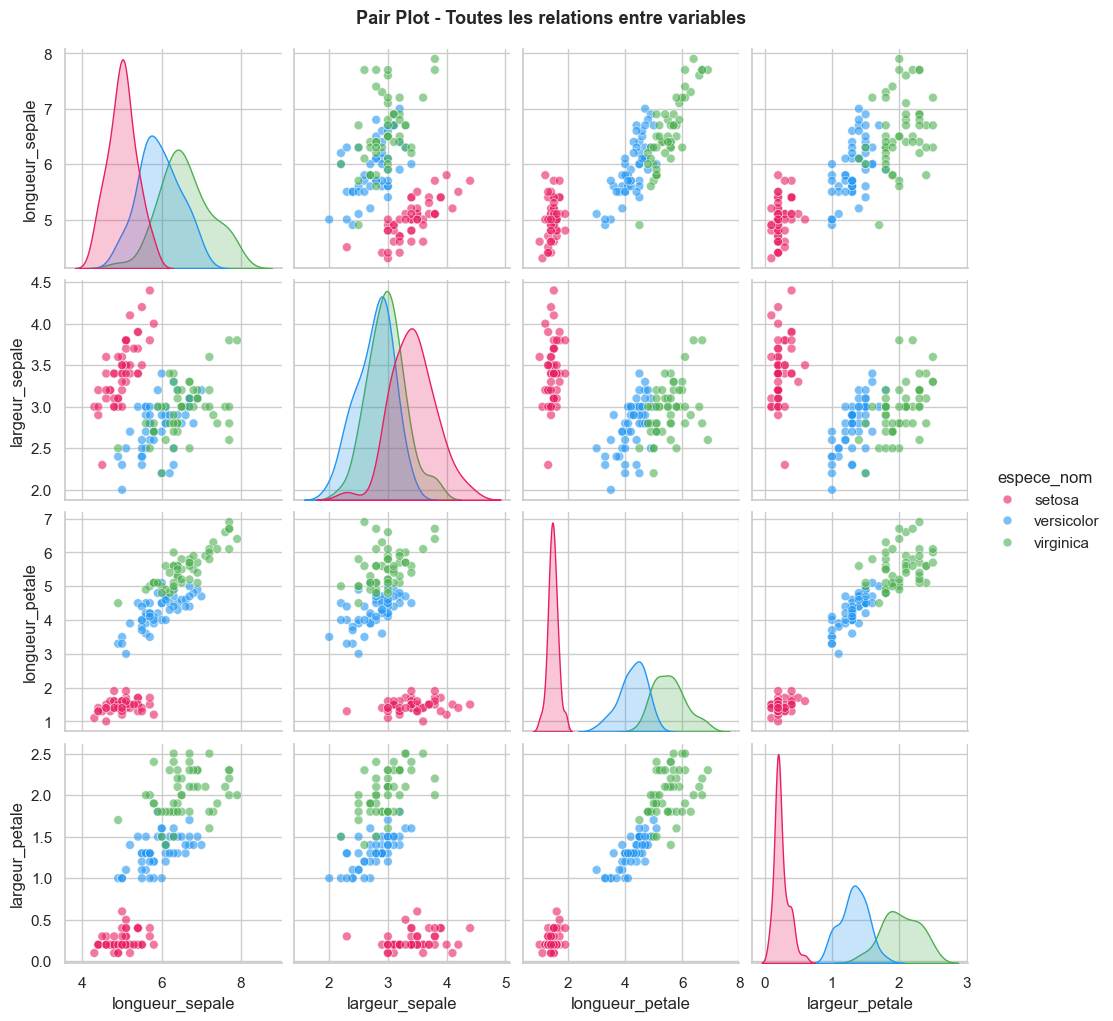

💡 Diagonale = distribution de chaque variable (KDE = densité)
   Autres cases = relation entre 2 variables


In [16]:
# Pair plot - vue complète de toutes les relations
g = sns.pairplot(df[cols_num + ['espece_nom']],
                 hue='espece_nom',
                 palette={'setosa': '#E91E63', 'versicolor': '#2196F3', 'virginica': '#4CAF50'},
                 diag_kind='kde',
                 plot_kws={'alpha': 0.6, 's': 40})

g.fig.suptitle('Pair Plot - Toutes les relations entre variables', y=1.02, fontsize=13, fontweight='bold')
plt.show()
print('💡 Diagonale = distribution de chaque variable (KDE = densité)')
print('   Autres cases = relation entre 2 variables')

## 8. Conclusion <a id='8'></a>

### Récapitulatif des outils d'exploration

| Étape | Fonction Python | Ce qu'elle apporte |
|-------|----------------|--------------------|
| Chargement | `pd.read_csv()` | Importer les données |
| Infos | `.info()`, `.dtypes` | Types et valeurs manquantes |
| Stats | `.describe()` | Résumé statistique |
| Distributions | Histogrammes, Boxplots | Répartition des valeurs |
| Valeurs manquantes | `.isnull().sum()` | Détecter les trous |
| Corrélations | `.corr()`, Heatmap | Relations linéaires |
| Relations | Scatter plot, Pair plot | Visualiser les liens |

### Checklist EDA ✅

- ✅ Charger et inspecter les données (forme, types)
- ✅ Calculer les statistiques descriptives
- ✅ Visualiser les distributions
- ✅ Identifier et traiter les valeurs manquantes
- ✅ Analyser les corrélations
- ✅ Identifier les relations entre variables

> 🎯 **Règle d'or** : Passez toujours du temps sur l'EDA. Un bon explorateur de données évite de nombreuses erreurs de modélisation !